# Password Strength Classification

In this project, password strength estimation is reformulated as a machine learning multi-class classification problem:

Given a password string, predict whether it is Weak, Medium, or Strong

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ0quTdrr4XtMnbR_1mTKN3_A2tm6TMlE00acHfoNY3kA&s=10' width='550'>

In [1]:
#Libraries
import pandas as pd
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# EDA

In [2]:
df = pd.read_csv('data.csv', on_bad_lines='skip')

In [3]:
df.sample(10)

,password,strength
166857,iyess90,0
663591,mario69,0
98184,xocuruv443,1
144343,megui29,0
579182,Th7QRgDAxOA5hPg0,2
161720,0UjNeZTQyNQpPjxa,2
216932,13269123A,1
590865,dnmguyh3,1
342189,yogesh1135,1
250124,superclip45,1


In [5]:
df.shape

(669640, 2)

In [7]:
df.isnull().sum()

password    1
strength    0
dtype: int64

<Axes: xlabel='strength', ylabel='count'>

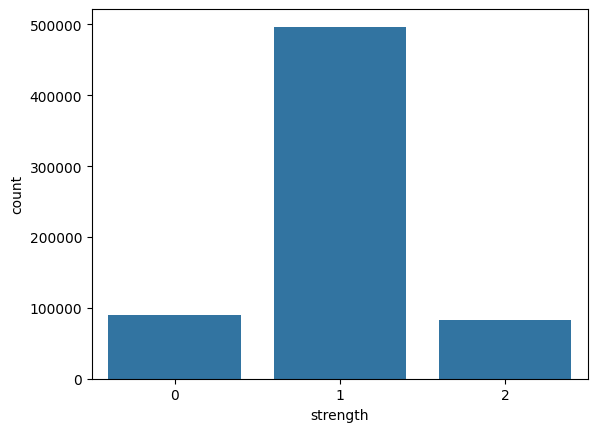

In [8]:
sns.countplot(x=df['strength'])

In [9]:
df = df.dropna(subset=["password"]).copy()

In [10]:
df["strength"].value_counts()

strength
1    496801
0     89701
2     83137
Name: count, dtype: int64

In [11]:
df.groupby("strength")["password"].apply(lambda x: x.str.len().mean())

strength
0     6.549604
1     9.618964
2    15.932497
Name: password, dtype: float64

In [12]:
df['password_length'] = df['password'].astype(str).str.len()

In [13]:
df['password_length'].describe()

count    669639.000000
mean          9.991648
std           2.819954
min           1.000000
25%           8.000000
50%           9.000000
75%          11.000000
max         220.000000
Name: password_length, dtype: float64

In [14]:
print("Passwords longer than 50 chars:", (df["password_length"] > 50).sum())
print("Passwords longer than 100 chars:", (df["password_length"] > 100).sum())

Passwords longer than 50 chars: 7
Passwords longer than 100 chars: 4


In [15]:
df.groupby("strength")["password_length"].describe()

,count,mean,std,min,25%,50%,75%,max
strength,,,,,,,,
0,89701.0,6.549604,0.509952,1.0,6.0,7.0,7.0,7.0
1,496801.0,9.618964,1.343117,8.0,9.0,9.0,10.0,13.0
2,83137.0,15.932497,2.020979,14.0,16.0,16.0,16.0,220.0


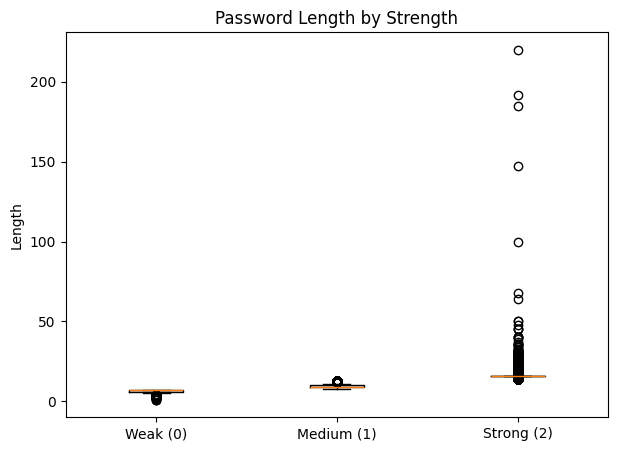

In [16]:
plt.figure(figsize=(7,5))
plt.boxplot(
    [df[df["strength"]==0]["password_length"],
     df[df["strength"]==1]["password_length"],
     df[df["strength"]==2]["password_length"]],
    labels=["Weak (0)", "Medium (1)", "Strong (2)"]
)
plt.title("Password Length by Strength")
plt.ylabel("Length")
plt.show()

In [17]:
passwords = df["password"].astype(str) # ensure passwords are strings

In [18]:
#  Calculate counts using vectorized string methods (No loops!)
df["n_digit"]  = passwords.str.count(r'\d')
df["n_lower"]  = passwords.str.count(r'[a-z]')
df["n_upper"]  = passwords.str.count(r'[A-Z]')
df["n_symbol"] = passwords.str.count(r"[^a-zA-Z0-9]")

In [19]:
#  Unique Ratio (Vectorized)
df["unique_ratio"] = passwords.apply(lambda x: len(set(x))) / df["password_length"]

In [21]:
df["unique_ratio"] = df["unique_ratio"].fillna(0)

In [22]:
df.head()

,password,strength,password_length,n_digit,n_lower,n_upper,n_symbol,unique_ratio
0,kzde5577,1,8,4,4,0,0,0.750000
1,kino3434,1,8,4,4,0,0,0.750000
2,visi7k1yr,1,9,2,7,0,0,0.888889
3,megzy123,1,8,3,5,0,0,1.000000
4,lamborghin1,1,11,1,10,0,0,1.000000


In [23]:
df.groupby("strength")[["n_digit","n_lower","n_upper","n_symbol","unique_ratio"]].mean()

,n_digit,n_lower,n_upper,n_symbol,unique_ratio
strength,,,,,
0,1.774741,4.673181,0.078238,0.023445,0.880941
1,3.449599,6.068683,0.081548,0.019134,0.854940
2,3.100509,6.771907,5.823460,0.236621,0.863091


In [24]:
df["complexity_score"] = (df["n_digit"] * 1) + \
                         (df["n_upper"] * 2) + \
                         (df["n_symbol"] * 3)

In [26]:
df["complexity_density"] = df["complexity_score"] / df["password_length"]

In [27]:
df[["password", "password_length", "complexity_score"]].head()

,password,password_length,complexity_score
0,kzde5577,8,4
1,kino3434,8,4
2,visi7k1yr,9,2
3,megzy123,8,3
4,lamborghin1,11,1


In [28]:
df.groupby("strength")[["complexity_score","complexity_density"]].describe()

complexity_score                                                     \
                    count       mean       std  min   25%   50%   75%    max   
strength                                                                       
0                 89701.0   2.001550  1.620489  0.0   1.0   2.0   2.0   21.0   
1                496801.0   3.670097  2.551913  1.0   2.0   3.0   4.0   35.0   
2                 83137.0  15.457293  5.196892  3.0  13.0  16.0  19.0  191.0   

         complexity_density                                                    \
                      count      mean       std       min       25%       50%   
strength                                                                        
0                   89701.0  0.311023  0.259220  0.000000  0.142857  0.285714   
1                  496801.0  0.382606  0.257462  0.076923  0.222222  0.333333   
2                   83137.0  0.972873  0.310141  0.100000  0.785714  1.000000   

                              
               75%       max  
strength                      
0         0.333333  3.000000  
1         0.454545  2.875000  
2         1.187500  2.444444

### Data Preprocessing

In [29]:
df = df.dropna().copy()

In [30]:
df["password"] = df["password"].astype(str)
df["strength"] = df["strength"].astype(int)

In [31]:
df["strength"].value_counts(normalize=True)

strength
1    0.741894
0    0.133954
2    0.124152
Name: proportion, dtype: float64

In [32]:
structural_features = ["password_length", "unique_ratio"]
char_counts         = ["n_digit", "n_lower", "n_upper", "n_symbol"]
complexity_metrics  = ["complexity_density"]

In [33]:
selected_features = structural_features + char_counts + complexity_metrics

In [34]:
x = df[selected_features].copy()
y = df["strength"].copy()

In [35]:
x = x.fillna(0)

In [36]:
x.head()

,password_length,unique_ratio,n_digit,n_lower,n_upper,n_symbol,complexity_density
0,8,0.750000,4,4,0,0,0.500000
1,8,0.750000,4,4,0,0,0.500000
2,9,0.888889,2,7,0,0,0.222222
3,8,1.000000,3,5,0,0,0.375000
4,11,1.000000,1,10,0,0,0.090909


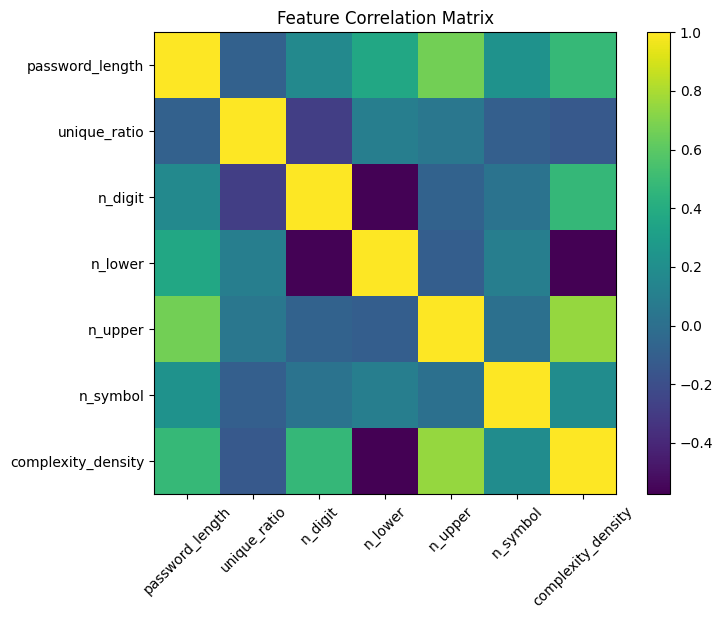

In [37]:
corr = x.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.show()

In [38]:
x_train, x_valid, y_train, y_valid = train_test_split(x,y,test_size=0.15,random_state=42,stratify=y)

In [39]:
y_train.value_counts(normalize=True)
y_valid.value_counts(normalize=True)

strength
1    0.741891
0    0.133953
2    0.124156
Name: proportion, dtype: float64

### Character n-grams (TF-IDF)

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [41]:
pw_train = df.loc[x_train.index, "password"]
pw_valid = df.loc[x_valid.index, "password"]

In [42]:
tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2, 3), max_features=1000)

In [43]:
x_train_tfidf = tfidf.fit_transform(pw_train)

In [44]:
x_valid_tfidf = tfidf.transform(pw_valid)

### Hybrid Feature Space

In [45]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

# Numeric space
x_train_numeric = csr_matrix(x_train.values)
x_valid_numeric = csr_matrix(x_valid.values)

# Hybrid feature space
x_train_hybrid = hstack([x_train_tfidf, x_train_numeric])
x_valid_hybrid = hstack([x_valid_tfidf, x_valid_numeric])

print("Hybrid Train Shape:", x_train_hybrid.shape)
print("Hybrid Valid Shape:", x_valid_hybrid.shape)

Hybrid Train Shape: (569193, 1007)
Hybrid Valid Shape: (100446, 1007)


### Modeling

In [47]:
from sklearn.metrics import accuracy_score, f1_score

In [49]:
L = LogisticRegression(max_iter=300, class_weight="balanced")

In [50]:
L.fit(x_train_hybrid, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,300
,multi_class,'deprecated'


In [51]:
pred = L.predict(x_valid_hybrid)

In [53]:
accuracy_score(y_valid, pred)

0.9998705772255739

In [55]:
print(classification_report (y_valid, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13455
           1       1.00      1.00      1.00     74520
           2       1.00      1.00      1.00     12471

    accuracy                           1.00    100446
   macro avg       1.00      1.00      1.00    100446
weighted avg       1.00      1.00      1.00    100446



<Axes: >

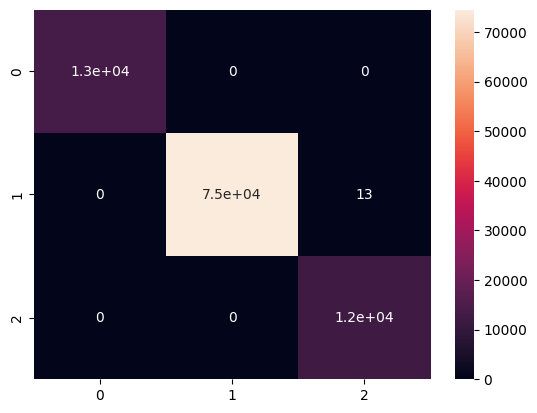

In [57]:
sns.heatmap(confusion_matrix(y_valid,pred),annot=True)

### Feature Importance & Interpretation

In [59]:
import numpy as np

In [60]:
feature_names = list(tfidf.get_feature_names_out()) + list(x_train.columns)

coef = L.coef_

importance = np.mean(np.abs(coef), axis=0)

idx = np.argsort(importance)[-20:]

for i in idx[::-1]:
    print(feature_names[i], round(importance[i], 4))

complexity_density 24.6264
password_length 7.3429
n_symbol 4.9697
00 2.7779
n_upper 2.5868
11 2.4882
55 2.2385
22 2.0593
aa 2.0343
000 2.0342
10 1.8348
unique_ratio 1.7878
111 1.729
88 1.671
99 1.6268
n_lower 1.6003
66 1.5908
33 1.4832
77 1.4468
oo 1.3898


The model confirms that password strength is primarily determined by structural complexity and character diversity, not just length.

Symbol usage, uppercase/lowercase balance, and repetitive-pattern detection all contribute to the final classification.